In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Carichiamo gli edifici
gdf = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat.json",
                    on_invalid="ignore")

# Puliamo i dati
gdf_clean = gdf[gdf['Bouwjaar'] > 1500].copy()

# Estraiamo le coordinate del centroide di ogni edificio
gdf_clean['x'] = gdf_clean.geometry.centroid.x
gdf_clean['y'] = gdf_clean.geometry.centroid.y

print(f"Edifici pronti per il clustering: {len(gdf_clean)}")
print(gdf_clean[['x', 'y', 'Bouwjaar']].head())

Edifici pronti per il clustering: 44504
            x          y  Bouwjaar
244  4.900848  52.375423      1515
245  4.905667  52.372036      1517
246  5.041957  52.308232      1550
247  4.896584  52.374393      1550
248  4.898849  52.375654      1550


In [3]:
# Prepariamo il dataset per il clustering
# Usiamo posizione + anno di costruzione
X = gdf_clean[['x', 'y', 'Bouwjaar']].values

# Normalizziamo — portiamo tutto sulla stessa scala
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dati normalizzati!")
print(f"Media dopo normalizzazione: {X_scaled.mean(axis=0).round(3)}")
print(f"Deviazione standard: {X_scaled.std(axis=0).round(3)}")

Dati normalizzati!
Media dopo normalizzazione: [-0. -0.  0.]
Deviazione standard: [1. 1. 1.]


In [4]:
# Applichiamo DBSCAN
# eps = distanza massima tra due punti per essere nello stesso cluster
# min_samples = numero minimo di punti per formare un cluster
dbscan = DBSCAN(eps=0.15, min_samples=50)
gdf_clean['cluster'] = dbscan.fit_predict(X_scaled)

# Risultati
n_clusters = len(set(gdf_clean['cluster'])) - (1 if -1 in gdf_clean['cluster'].values else 0)
n_noise = (gdf_clean['cluster'] == -1).sum()

print(f"Cluster trovati: {n_clusters}")
print(f"Edifici non classificati (rumore): {n_noise}")
print(f"Distribuzione cluster:")
print(gdf_clean['cluster'].value_counts().head(10))

Cluster trovati: 38
Edifici non classificati (rumore): 6194
Distribuzione cluster:
cluster
 0     17834
-1      6194
 3      4889
 15     3383
 9      2712
 2      2414
 16     1347
 30     1148
 11      625
 25      586
Name: count, dtype: int64


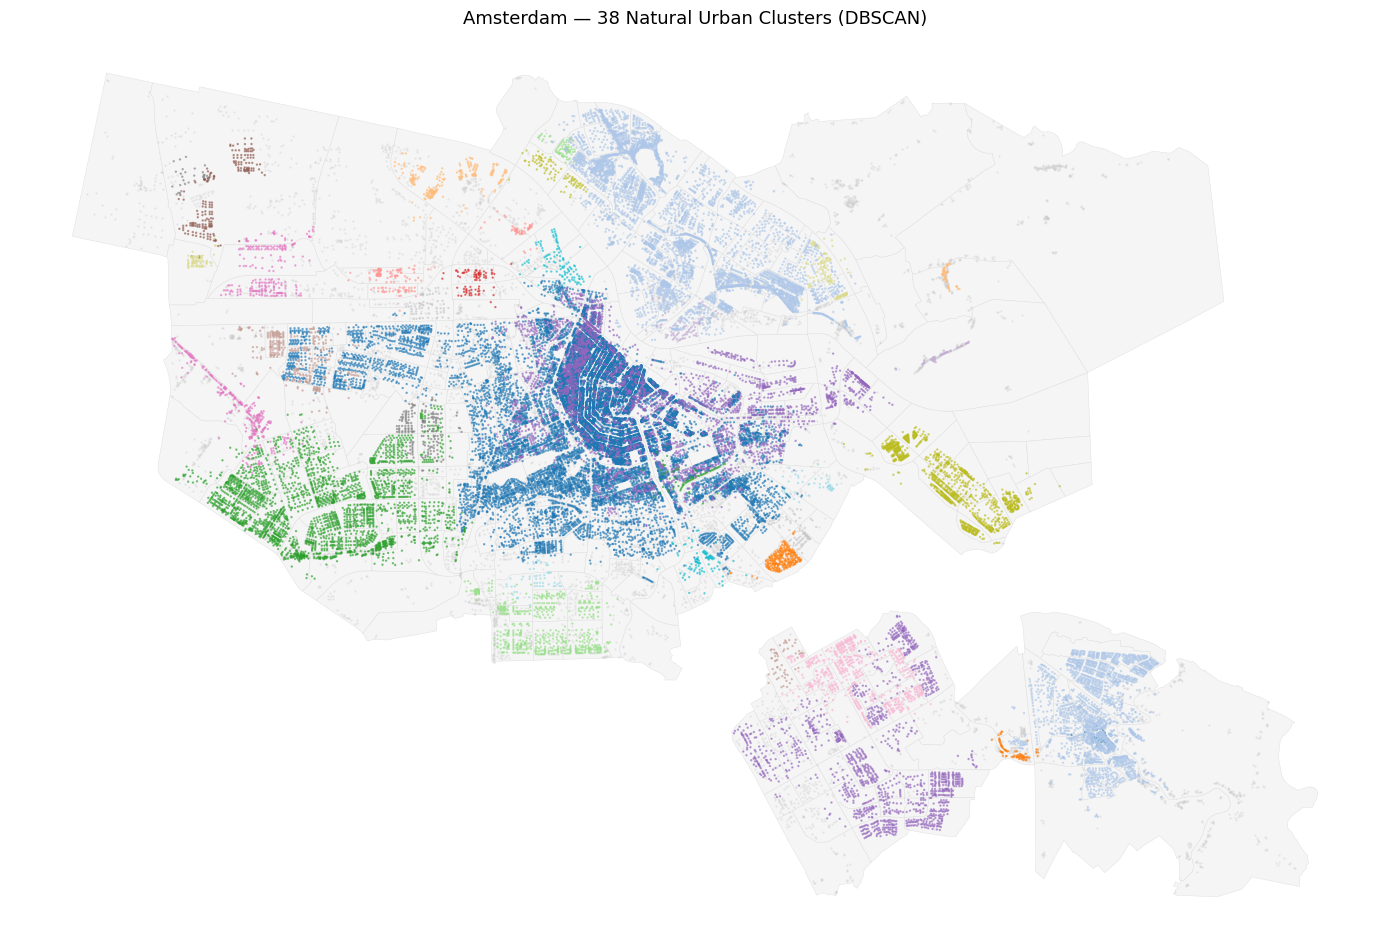

In [5]:
import matplotlib.cm as cm

fig, ax = plt.subplots(1, 1, figsize=(14, 11))

# Sfondo
buurten = gpd.read_file(r"C:\Users\andre\OneDrive\Desktop\PARAMETRIC DESIGN\geojson_lnglat_2.json")
buurten.plot(ax=ax, color='#f5f5f5', edgecolor='#dddddd', linewidth=0.3)

# Edifici rumore in grigio
rumore = gdf_clean[gdf_clean['cluster'] == -1]
ax.scatter(rumore['x'], rumore['y'], c='#cccccc', s=0.5, alpha=0.3)

# Edifici nei cluster colorati
cluster_data = gdf_clean[gdf_clean['cluster'] != -1]
scatter = ax.scatter(
    cluster_data['x'], 
    cluster_data['y'],
    c=cluster_data['cluster'],
    cmap='tab20',
    s=0.5,
    alpha=0.6
)

ax.set_title(f'Amsterdam — {n_clusters} Natural Urban Clusters (DBSCAN)', fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.savefig('amsterdam_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

In [6]:
# Caratteristiche per cluster
stats_cluster = gdf_clean[gdf_clean['cluster'] != -1].groupby('cluster').agg(
    Edifici=('Bouwjaar', 'count'),
    Anno_medio=('Bouwjaar', 'mean'),
    Anno_mediano=('Bouwjaar', 'median'),
    x_centro=('x', 'mean'),
    y_centro=('y', 'mean')
).round(0).sort_values('Edifici', ascending=False)

print(stats_cluster.head(15))

         Edifici  Anno_medio  Anno_mediano  x_centro  y_centro
cluster                                                       
0          17834      1861.0        1897.0       5.0      52.0
3           4889      1962.0        1958.0       5.0      52.0
15          3383      1993.0        1992.0       5.0      52.0
9           2712      1986.0        1991.0       5.0      52.0
2           2414      1980.0        1983.0       5.0      52.0
16          1347      1983.0        1983.0       5.0      52.0
30          1148      2012.0        2009.0       5.0      52.0
11           625      1965.0        1964.0       5.0      52.0
25           586      2008.0        2007.0       5.0      52.0
21           327      2001.0        2000.0       5.0      52.0
23           306      2001.0        2000.0       5.0      52.0
5            261      1925.0        1925.0       5.0      52.0
24           223      2001.0        2002.0       5.0      52.0
7            215      1958.0        1958.0       5.0   

In [7]:
stats_cluster = gdf_clean[gdf_clean['cluster'] != -1].groupby('cluster').agg(
    Edifici=('Bouwjaar', 'count'),
    Anno_medio=('Bouwjaar', 'mean'),
    Anno_mediano=('Bouwjaar', 'median'),
    x_centro=('x', 'mean'),
    y_centro=('y', 'mean')
)
stats_cluster['Edifici'] = stats_cluster['Edifici'].astype(int)
stats_cluster['Anno_medio'] = stats_cluster['Anno_medio'].round(0).astype(int)
stats_cluster['Anno_mediano'] = stats_cluster['Anno_mediano'].astype(int)
stats_cluster['x_centro'] = stats_cluster['x_centro'].round(4)
stats_cluster['y_centro'] = stats_cluster['y_centro'].round(4)
stats_cluster = stats_cluster.sort_values('Edifici', ascending=False)

print(stats_cluster.head(15))

         Edifici  Anno_medio  Anno_mediano  x_centro  y_centro
cluster                                                       
0          17834        1861          1897    4.8865   52.3670
3           4889        1962          1958    4.9142   52.4026
15          3383        1993          1992    4.9050   52.3705
9           2712        1986          1991    4.8061   52.3509
2           2414        1980          1983    5.0408   52.3117
16          1347        1983          1983    4.9742   52.3042
30          1148        2012          2009    4.9959   52.3550
11           625        1965          1964    4.8724   52.3284
25           586        2008          2007    4.9682   52.3191
21           327        2001          2000    4.7970   52.3784
23           306        2001          2000    4.7796   52.3687
5            261        1925          1925    4.9448   52.3408
24           223        2001          2002    4.7881   52.3945
7            215        1958          1958    4.8431   

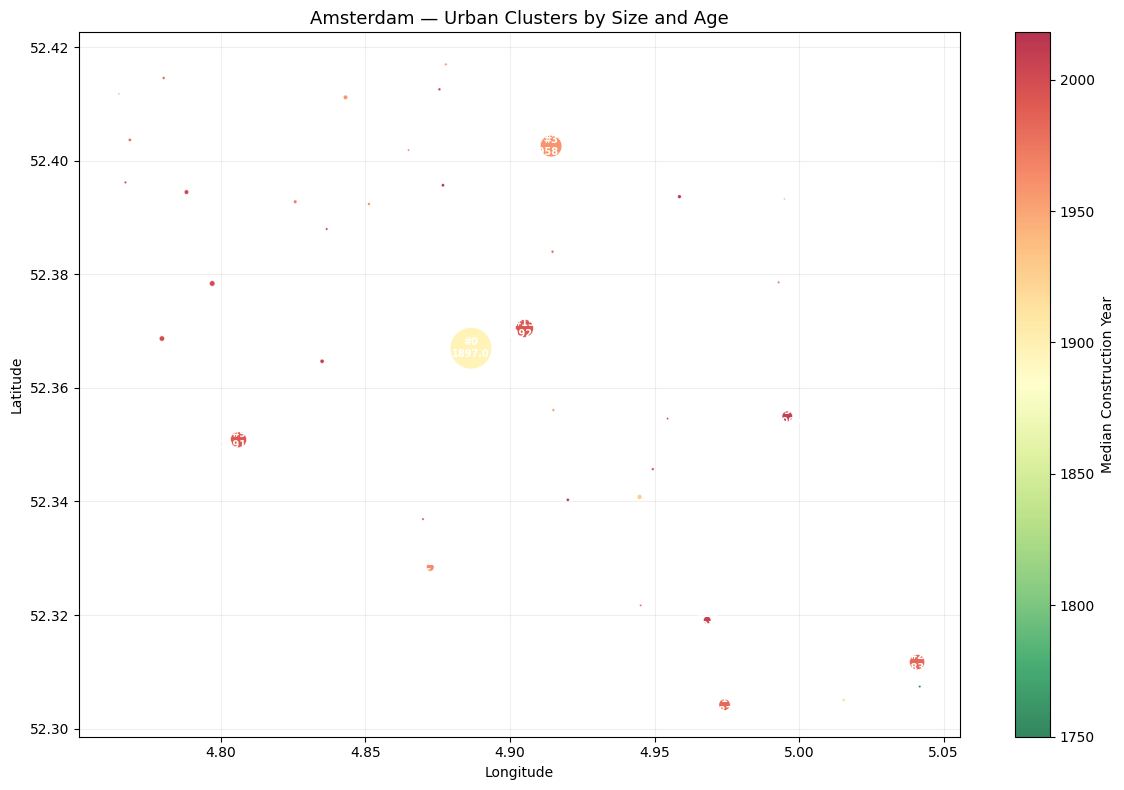

In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(
    stats_cluster['x_centro'],
    stats_cluster['y_centro'],
    s=stats_cluster['Edifici'] / 20,
    c=stats_cluster['Anno_mediano'],
    cmap='RdYlGn_r',
    alpha=0.8,
    edgecolors='white',
    linewidth=0.5
)

# Etichette per i cluster più grandi
for idx, row in stats_cluster[stats_cluster['Edifici'] > 500].iterrows():
    ax.annotate(f"#{idx}\n{row['Anno_mediano']}",
                xy=(row['x_centro'], row['y_centro']),
                fontsize=7, ha='center', va='center',
                color='white', fontweight='bold')

plt.colorbar(scatter, ax=ax, label='Median Construction Year')
ax.set_title('Amsterdam — Urban Clusters by Size and Age', fontsize=13)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig('amsterdam_cluster_bubbles.png', dpi=150, bbox_inches='tight')
plt.show()